# Notebook 05 — Training & Optimization (PyTorch)

**Objective:** Compile, configure, and train the custom CNN models built in Notebook 04 on the PlantVillage dataset preprocessed in Notebook 03.

**Topics Covered:**
- ✅ Compile model: Cross-Entropy loss (label smoothing=0.1), Adam optimiser (lr=0.001)
- ✅ Top-1 and Top-3 accuracy metrics
- ✅ Callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
- ✅ Training loop: batch_size=32, max_epochs=50
- ✅ Loss & accuracy visualisation with gap analysis

**Input:**
- `data/splits/train.csv`, `val.csv` (from Notebook 03)
- `architecture/baseline_model_state.pth` (from Notebook 04)

**Output:**
- `models/best_model.pth` — best checkpoint weights
- `models/training_history.json` — full epoch-level metrics
- `reports/05a_loss_curves.png`
- `reports/05b_accuracy_curves.png`
- `logs/tensorboard/` — TensorBoard event files

##  Import Packages

In [1]:
import json
import os
import os
import time
import warnings
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import IPython

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms
from PIL import Image
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})
sns.set_palette('viridis')

print(f'PyTorch version : {torch.__version__}')
print(f'GPU available   : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name        : {torch.cuda.get_device_name(0)}')
print('✅ All packages imported successfully')

PyTorch version : 2.10.0+cu128
GPU available   : True
GPU name        : Tesla T4
✅ All packages imported successfully


##  Paths & Global Constants

In [2]:
import re as _re
import pandas as _pd
from sklearn.model_selection import train_test_split as _tts

# ── Resolve project root (Windows local — one level above notebooks/) ─────────
PROJECT_ROOT = Path.cwd().parent
print(f'📂  Project root → {PROJECT_ROOT}')

DATA_DIR     = PROJECT_ROOT / 'data'
RAW_DIR      = DATA_DIR / 'raw' / 'plant_village'
METADATA_DIR = DATA_DIR / 'metadata'
SPLITS_DIR   = DATA_DIR / 'splits'
ARCH_DIR     = PROJECT_ROOT / 'architecture'
MODELS_DIR   = PROJECT_ROOT / 'models'
REPORTS_DIR  = PROJECT_ROOT / 'reports'
LOGS_DIR     = PROJECT_ROOT / 'logs' / 'tensorboard'

for _d in [METADATA_DIR, SPLITS_DIR, MODELS_DIR, REPORTS_DIR, LOGS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'RAW_DIR      : {RAW_DIR}')
print(f'Found        : {RAW_DIR.exists()}')

_IMG_EXTS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

if not RAW_DIR.exists():
    raise RuntimeError(
        f"RAW_DIR not found:\n  {RAW_DIR}\n"
        "Expected:\n"
        "  Project2_AgroLens_AI\\data\\raw\\plant_village\\<class_folder>\\<images>\n"
        "Make sure the notebook is inside Project2_AgroLens_AI\\notebooks\\"
    )

# ── List class folders (pure Python, Windows-safe) ────────────────────────────
_cls_folders = sorted([p for p in RAW_DIR.iterdir() if p.is_dir()])
print(f'Class folders found: {len(_cls_folders)}')
if _cls_folders:
    print(f'  Sample: {_cls_folders[0].name}')

# ── Check if existing CSVs are valid ──────────────────────────────────────────
def _csvs_valid():
    _tc = SPLITS_DIR / 'train.csv'
    if not _tc.exists(): return False
    try:
        _r = _pd.read_csv(_tc, nrows=1)
        _pc = next((c for c in ['path','filepath','file_path'] if c in _r.columns), None)
        if not _pc: return False
        return Path(str(_r[_pc].iloc[0])).exists()
    except Exception: return False

# ── Build CSVs from images ────────────────────────────────────────────────────
if not _csvs_valid():
    print('\n🔄  Building split CSVs ...')

    def _parse_label(folder):
        if '___' in folder: crop, dis = folder.split('___', 1)
        elif '__' in folder: crop, dis = folder.split('__', 1)
        else: crop, dis = folder, 'unknown'
        return {'crop': crop.replace('_',' ').strip(), 'disease': dis.replace('_',' ').strip()}

    _records = []
    for _cls_dir in _cls_folders:
        _meta = _parse_label(_cls_dir.name)
        try:
            _imgs = [p for p in _cls_dir.iterdir() if p.suffix in _IMG_EXTS]
            for _img in _imgs:
                _records.append({
                    'path'     : str(_img),
                    'filename' : _img.name,
                    'extension': _img.suffix.lower(),
                    'label'    : _cls_dir.name,
                    'crop'     : _meta['crop'],
                    'disease'  : _meta['disease'],
                })
            print(f'  📁  {_cls_dir.name}: {len(_imgs)} images')
        except OSError as e:
            print(f'  ⚠️  {_cls_dir.name}: {e}')

    print(f'\n  Total images scanned : {len(_records):,}')
    if not _records:
        raise RuntimeError('0 images found. Check that image files are inside class folders.')

    _df = _pd.DataFrame(_records).drop_duplicates(subset='path')

    # ── Filter: keep only classes with >= MIN_IMAGES_PER_CLASS images ─────────
    MIN_IMAGES_PER_CLASS = 15
    _counts_before = _df['label'].value_counts()
    _dropped = _counts_before[_counts_before < MIN_IMAGES_PER_CLASS]
    if len(_dropped):
        print(f'\n  ⚠️  Dropping {len(_dropped)} class(es) with < {MIN_IMAGES_PER_CLASS} images:')
        for _lbl, _cnt in _dropped.items():
            print(f'     • {_lbl}: {_cnt} image(s)')
        _df = _df[_df['label'].isin(_counts_before[_counts_before >= MIN_IMAGES_PER_CLASS].index)]
        _df = _df.reset_index(drop=True)

    _counts_after = _df['label'].value_counts()
    print(f'\n  ✅  Classes kept  : {len(_counts_after)}')
    print(f'  ✅  Images kept   : {len(_df):,}')
    print(f'  ✅  Min per class : {_counts_after.min()}')
    print(f'  ✅  Max per class : {_counts_after.max()}')

    _unique_labels = sorted(_df['label'].unique())
    _label_to_id   = {l: i for i, l in enumerate(_unique_labels)}
    _df['label_id'] = _df['label'].map(_label_to_id)

    _pd.DataFrame([{'label_id': v, 'label': k} for k, v in _label_to_id.items()]
                  ).to_csv(METADATA_DIR / 'label_mapping.csv', index=False)

    # stratified split — needs >=2 samples per class; use label for stratify
    _tr, _tmp = _tts(_df, test_size=0.30, stratify=_df['label'], random_state=42)
    _va, _te  = _tts(_tmp, test_size=0.50, stratify=_tmp['label'], random_state=42)
    for _s, _n in [(_tr,'train'), (_va,'val'), (_te,'test')]:
        _s.to_csv(SPLITS_DIR / f'{_n}.csv', index=False)

    NUM_CLASSES = len(_unique_labels)
    print(f'\n  ✅  train={len(_tr):,}  val={len(_va):,}  test={len(_te):,}  classes={NUM_CLASSES}')
    print(f'  ✅  CSVs saved → {SPLITS_DIR}')
else:
    _t = _pd.read_csv(SPLITS_DIR / 'train.csv')
    NUM_CLASSES = _t['label'].nunique() if 'label' in _t.columns else 38
    print(f'✅  CSVs already valid → {SPLITS_DIR}')

IMG_HEIGHT   = 224
IMG_WIDTH    = 224
IMG_CHANNELS = 3

BATCH_SIZE        = 8
MAX_EPOCHS        = 10
LEARNING_RATE     = 1e-3
LABEL_SMOOTHING   = 0.1
SEED              = 42

EARLY_STOP_PATIENCE = 10
REDUCE_LR_PATIENCE  = 5
REDUCE_LR_FACTOR    = 0.5
REDUCE_LR_MIN       = 1e-6

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'\nDevice       : {DEVICE}')
print(f'NUM_CLASSES  : {NUM_CLASSES}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Max epochs   : {MAX_EPOCHS}')
print('✅ Setup complete — ready to train.')


📂  Project root → /content/drive/MyDrive/Project2_AgroLens_AI


PROJECT_ROOT : /content/drive/MyDrive/Project2_AgroLens_AI
RAW_DIR      : /content/drive/MyDrive/Project2_AgroLens_AI/data/raw/plant_village
Found        : True
Class folders found: 15
  Sample: Pepper__bell___Bacterial_spot
✅  CSVs already valid → /content/drive/MyDrive/Project2_AgroLens_AI/data/splits

Device       : cuda
NUM_CLASSES  : 15
Batch size   : 8
Max epochs   : 10
✅ Setup complete — ready to train.


##  Dataset & DataLoaders

In [3]:
# ── PlantVillage Dataset ──────────────────────────────────────────────────────
# The setup cell above guarantees that split CSVs contain valid absolute paths
# on the current machine, so no path-translation logic is needed here.
class PlantVillageDataset(Dataset):
    """
    Reads a split CSV produced by the setup cell (or NB01/NB03).
    Columns: 'path' (absolute image path), 'label_id' (int), 'label' (str).
    """

    _PATH_COLS  = ['path', 'filepath', 'file_path', 'image_path', 'filename']
    _LABEL_COLS = ['label_id', 'label_idx', 'class_id', 'class_idx',
                   'label', 'class', 'target']

    def __init__(self, csv_path: Path, transform=None, label_map: dict = None):
        _df = pd.read_csv(csv_path)
        cols = _df.columns.tolist()

        # ── Resolve columns ───────────────────────────────────────────────
        self.path_col = next((c for c in self._PATH_COLS  if c in cols), None)
        self.label_col= next((c for c in self._LABEL_COLS if c in cols), None)
        if self.path_col  is None:
            raise KeyError(f"No image-path column in {csv_path}.\nColumns: {cols}")
        if self.label_col is None:
            raise KeyError(f"No label column in {csv_path}.\nColumns: {cols}")

        # ── Encode string labels if needed ────────────────────────────────
        if not pd.api.types.is_integer_dtype(_df[self.label_col]):
            if label_map is None:
                classes   = sorted(_df[self.label_col].unique())
                label_map = {c: i for i, c in enumerate(classes)}
            _df[self.label_col] = _df[self.label_col].map(label_map)

        # ── Drop any rows whose file is missing (safety net) ─────────────
        _before = len(_df)
        _df = _df[_df[self.path_col].apply(lambda p: Path(str(p)).is_file())]
        _df = _df.reset_index(drop=True)
        _skipped = _before - len(_df)
        if _skipped:
            print(f"  ⚠️  {_skipped:,} rows skipped (file not found). "
                  f"{len(_df):,} usable.")
        if len(_df) == 0:
            raise RuntimeError(
                f"\n❌ No valid images for {csv_path.name}\n"
                f"   path column : '{self.path_col}'\n"
                f"   sample path : {pd.read_csv(csv_path, nrows=1)[self.path_col].iloc[0]}\n"
                f"   Re-run the setup cell (Cell 5) — it will re-download and rebuild CSVs."
            )

        self.df        = _df
        self.label_map = label_map
        self.transform = transform
        print(f"  [{csv_path.name}] {len(self.df):,} rows | "
              f"path='{self.path_col}' | label='{self.label_col}'")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(str(row[self.path_col])).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(int(row[self.label_col]), dtype=torch.long)
        return image, label

# ── Transforms ────────────────────────────────────────────────────────────────
# Training: same augmentation strategy as Notebook 03
train_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.RandomResizedCrop(size=(IMG_HEIGHT, IMG_WIDTH), scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.2),
    transforms.ToTensor(),                   # [0,255] → [0,1]
    transforms.Normalize(                    # ImageNet-style normalisation
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    ),
])

# Val / Test: no augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    ),
])

# ── Instantiate datasets ──────────────────────────────────────────────────────
train_dataset = PlantVillageDataset(SPLITS_DIR / 'train.csv', transform=train_transform)
label_map     = train_dataset.label_map

val_dataset   = PlantVillageDataset(SPLITS_DIR / 'val.csv',   transform=val_transform,
                                    label_map=label_map)

# ── Quick-test subset (limits to 16 train / 8 val images for fast iteration) ──
from torch.utils.data import Subset
QUICK_TEST = True   # set False for full training run
if QUICK_TEST:
    train_dataset = Subset(train_dataset, range(min(16, len(train_dataset))))
    val_dataset   = Subset(val_dataset,   range(min(8,  len(val_dataset))))
    print(f'⚡ QUICK_TEST mode: {len(train_dataset)} train / {len(val_dataset)} val samples')

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,           # 0 = no multiprocessing (safe on Windows)
    pin_memory=False,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,           # 0 = no multiprocessing (safe on Windows)
    pin_memory=False,
)

print(f'Train samples : {len(train_dataset):,}  |  batches: {len(train_loader):,}')
print(f'Val   samples : {len(val_dataset):,}  |  batches: {len(val_loader):,}')
print(f'Classes       : {NUM_CLASSES}')
print('✅ DataLoaders ready')

  [train.csv] 14,446 rows | path='path' | label='label_id'


  [val.csv] 3,096 rows | path='path' | label='label_id'
⚡ QUICK_TEST mode: 16 train / 8 val samples
Train samples : 16  |  batches: 2
Val   samples : 8  |  batches: 1
Classes       : 15
✅ DataLoaders ready


##  Re-define Model Architecture

> Copied verbatim from Notebook 04 so this notebook is self-contained.  
> We then load the saved weights from `architecture/`.

In [4]:
# ── Delete stale checkpoint if class count doesn't match ──────────────────────
# If the saved .pth was trained with a different number of classes,
# delete it so the model starts fresh with the correct architecture.
import torch as _torch
from pathlib import Path as _Path

_ckpt_path = ARCH_DIR / 'baseline_model_state.pth'
if _ckpt_path.exists():
    try:
        _sd = _torch.load(_ckpt_path, map_location='cpu', weights_only=True)
        _ckpt_n = _sd['output.weight'].shape[0]
        if _ckpt_n != NUM_CLASSES:
            print(f'⚠️  Checkpoint has {_ckpt_n} classes, current run has {NUM_CLASSES}.')
            print(f'   Deleting stale checkpoint so model starts fresh.')
            _ckpt_path.unlink()
            print(f'   Deleted: {_ckpt_path}')
        else:
            print(f'✅ Checkpoint class count matches ({_ckpt_n}) — will load weights.')
    except Exception as _e:
        print(f'⚠️  Could not inspect checkpoint ({_e}) — deleting to be safe.')
        _ckpt_path.unlink()
else:
    print('ℹ️  No checkpoint found — model will start from random initialisation.')


ℹ️  No checkpoint found — model will start from random initialisation.


In [5]:
class BaselineCNN(nn.Module):
    """
    Baseline CNN — 3 convolutional blocks (32→64→128 filters) +
    two fully-connected layers.
    """

    def __init__(self, input_channels=3, num_classes=38, dropout_rate=0.3):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(dropout_rate),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(dropout_rate),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(dropout_rate),
        )
        # After 3× MaxPool2d(2) on 224×224: 224/8 = 28
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.relu_fc = nn.ReLU(inplace=True)
        self.dropout_fc = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(256, 128)
        self.relu_fc2 = nn.ReLU(inplace=True)
        self.dropout_fc2 = nn.Dropout(dropout_rate)
        self.output = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.dropout_fc(self.relu_fc(self.fc1(x)))
        x = self.dropout_fc2(self.relu_fc2(self.fc2(x)))
        return self.output(x)          # raw logits — loss fn applies softmax


class CompactCNN(nn.Module):
    """
    Lightweight alternative — 3 shallow blocks (16→32→64 filters).
    """

    def __init__(self, input_channels=3, num_classes=38, dropout_rate=0.3):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(input_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(dropout_rate),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(dropout_rate),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(dropout_rate),
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.relu_fc = nn.ReLU(inplace=True)
        self.dropout_fc = nn.Dropout(dropout_rate)
        self.output = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.dropout_fc(self.relu_fc(self.fc1(x)))
        return self.output(x)


# ── Instantiate the Baseline model ────────────────────────────────────────────
model = BaselineCNN(input_channels=IMG_CHANNELS, num_classes=NUM_CLASSES).to(DEVICE)

# ── Optionally reload pre-saved weights from Notebook 04 ─────────────────────
baseline_state_path = ARCH_DIR / 'baseline_model_state.pth'
if baseline_state_path.exists():
    _ckpt = torch.load(baseline_state_path, map_location=DEVICE, weights_only=True)
    _ckpt_classes = _ckpt.get('output.weight', _ckpt.get('output.bias', None))
    _ckpt_n = _ckpt_classes.shape[0] if _ckpt_classes is not None else None
    if _ckpt_n is not None and _ckpt_n != NUM_CLASSES:
        print(f'⚠️  Checkpoint has {_ckpt_n} classes but model has {NUM_CLASSES} — skipping output layer.')
        _ckpt = {k: v for k, v in _ckpt.items() if not k.startswith('output.')}
        model.load_state_dict(_ckpt, strict=False)
        print(f'✅ Partial weights loaded (output layer re-initialised for {NUM_CLASSES} classes).')
    else:
        model.load_state_dict(_ckpt)
        print(f'✅ Loaded weights from: {baseline_state_path}')
else:
    print('ℹ️  No saved weights found — starting from random initialisation')

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal params      : {total_params:,}')
print(f'Trainable params  : {trainable:,}')
print(f'Model on device   : {DEVICE}')

ℹ️  No saved weights found — starting from random initialisation

Total params      : 26,012,207
Trainable params  : 26,012,207
Model on device   : cuda


## Compile: Loss, Optimiser & Metrics

| Component | Choice | Notes |
|-----------|--------|-------|
| Loss | `CrossEntropyLoss` | `label_smoothing=0.1` built-in (PyTorch ≥ 1.10) |
| Optimiser | `Adam` | `lr=0.001`, default betas |
| Metric 1 | Top-1 Accuracy | % of correct top predictions |
| Metric 2 | Top-3 Accuracy | Correct label in top-3 predictions |

In [6]:
# ── Loss function ─────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# ── Optimiser ─────────────────────────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ── Metric helpers ────────────────────────────────────────────────────────────
def top_k_accuracy(outputs: torch.Tensor, targets: torch.Tensor, k: int = 1) -> float:
    """
    Compute top-k accuracy for a batch.
    outputs : (N, C) raw logits
    targets : (N,)  ground-truth class indices
    """
    with torch.no_grad():
        top_k = outputs.topk(k, dim=1).indices          # (N, k)
        correct = top_k.eq(targets.view(-1, 1).expand_as(top_k))
        return correct.any(dim=1).float().mean().item()

print('✅ Criterion :', criterion)
print('✅ Optimiser :', optimizer)
print('✅ Metrics   : Top-1 Accuracy, Top-3 Accuracy')

✅ Criterion : CrossEntropyLoss()
✅ Optimiser : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
✅ Metrics   : Top-1 Accuracy, Top-3 Accuracy


##  Configure Callbacks

PyTorch does not ship Keras-style callbacks, so each one is implemented as a lightweight helper class that wraps the standard PyTorch schedulers / logic.

In [7]:
# ────────────────────────────────────────────────────────────────────────────
# 🛑  Early Stopping
# ────────────────────────────────────────────────────────────────────────────
class EarlyStopping:
    """
    Stops training if `monitor` metric does not improve for `patience` epochs.
    Mode 'min' → lower is better (loss); 'max' → higher is better (accuracy).
    """
    def __init__(self, patience: int = 10, mode: str = 'min', min_delta: float = 1e-4):
        self.patience   = patience
        self.mode       = mode
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score: float) -> bool:
        improved = (
            self.best_score is None
            or (self.mode == 'min' and score < self.best_score - self.min_delta)
            or (self.mode == 'max' and score > self.best_score + self.min_delta)
        )
        if improved:
            self.best_score = score
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        return self.stop


# ────────────────────────────────────────────────────────────────────────────
# ⬇️  ReduceLROnPlateau  (PyTorch built-in)
# ────────────────────────────────────────────────────────────────────────────
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode      = 'min',
    factor    = REDUCE_LR_FACTOR,
    patience  = REDUCE_LR_PATIENCE,
    min_lr    = REDUCE_LR_MIN,
)

# ────────────────────────────────────────────────────────────────────────────
# 💾  ModelCheckpoint
# ────────────────────────────────────────────────────────────────────────────
class ModelCheckpoint:
    """
    Saves model weights whenever validation loss improves.
    """
    def __init__(self, filepath: Path, mode: str = 'min'):
        self.filepath   = filepath
        self.mode       = mode
        self.best_score = None

    def __call__(self, score: float, model: nn.Module) -> bool:
        saved = False
        improved = (
            self.best_score is None
            or (self.mode == 'min' and score < self.best_score)
            or (self.mode == 'max' and score > self.best_score)
        )
        if improved:
            self.best_score = score
            torch.save(model.state_dict(), self.filepath)
            saved = True
        return saved


# ────────────────────────────────────────────────────────────────────────────
# 📊  TensorBoard Writer
# ────────────────────────────────────────────────────────────────────────────
writer = SummaryWriter(log_dir=str(LOGS_DIR))

# ── Instantiate callbacks ──────────────────────────────────────────────────
early_stopper = EarlyStopping(patience=EARLY_STOP_PATIENCE, mode='min')
checkpointer  = ModelCheckpoint(filepath=MODELS_DIR / 'best_model.pth', mode='min')

print('✅ Callbacks configured:')
print(f'   🛑 EarlyStopping        patience={EARLY_STOP_PATIENCE}, monitor=val_loss')
print(f'   ⬇️  ReduceLROnPlateau    patience={REDUCE_LR_PATIENCE}, factor={REDUCE_LR_FACTOR}')
print(f'   💾 ModelCheckpoint      → {MODELS_DIR / "best_model.pth"}')
print(f'   📊 TensorBoard          → {LOGS_DIR}')

✅ Callbacks configured:
   🛑 EarlyStopping        patience=10, monitor=val_loss
   ⬇️  ReduceLROnPlateau    patience=5, factor=0.5
   💾 ModelCheckpoint      → /content/drive/MyDrive/Project2_AgroLens_AI/models/best_model.pth
   📊 TensorBoard          → /content/drive/MyDrive/Project2_AgroLens_AI/logs/tensorboard


##  Training Loop

- **Batch size:** 32  
- **Max epochs:** 50  
- Metrics printed every epoch; TensorBoard updated in real-time

In [8]:
# ── Helper: one training epoch ────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, running_top1, running_top3 = 0.0, 0.0, 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping — prevents NaN loss spikes
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        running_top1 += top_k_accuracy(outputs, labels, k=1)
        running_top3 += top_k_accuracy(outputs, labels, k=3)

    n = len(loader)
    return running_loss / n, running_top1 / n, running_top3 / n


# ── Helper: one validation epoch ──────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, running_top1, running_top3 = 0.0, 0.0, 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item()
        running_top1 += top_k_accuracy(outputs, labels, k=1)
        running_top3 += top_k_accuracy(outputs, labels, k=3)

    n = len(loader)
    return running_loss / n, running_top1 / n, running_top3 / n


# ── Training history accumulator ──────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_top3': [], 'val_top3': [],
    'lr': [],
}

HEADER = (
    f"{'Epoch':>6}  {'Train Loss':>11}  {'Val Loss':>9}  "
    f"{'Train Acc':>10}  {'Val Acc':>8}  {'Val Top3':>9}  {'LR':>10}  Saved?"
)
print(HEADER)
print('─' * len(HEADER))

train_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    ep_start = time.time()

    # ── Train ────────────────────────────────────────────────────────────
    t_loss, t_top1, t_top3 = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    # ── Validate ─────────────────────────────────────────────────────────
    v_loss, v_top1, v_top3 = evaluate(
        model, val_loader, criterion, DEVICE
    )

    cur_lr = optimizer.param_groups[0]['lr']

    # ── Scheduler step (on val loss) ─────────────────────────────────────
    scheduler.step(v_loss)

    # ── Checkpoint ───────────────────────────────────────────────────────
    saved = checkpointer(v_loss, model)

    # ── Early stopping ────────────────────────────────────────────────────
    stopped = early_stopper(v_loss)

    # ── Record history ────────────────────────────────────────────────────
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_top1)
    history['val_acc'].append(v_top1)
    history['train_top3'].append(t_top3)
    history['val_top3'].append(v_top3)
    history['lr'].append(cur_lr)

    # ── TensorBoard ───────────────────────────────────────────────────────
    writer.add_scalars('Loss',     {'train': t_loss, 'val': v_loss}, epoch)
    writer.add_scalars('Accuracy', {'train': t_top1, 'val': v_top1}, epoch)
    writer.add_scalars('Top3 Acc', {'train': t_top3, 'val': v_top3}, epoch)
    writer.add_scalar('LR', cur_lr, epoch)

    # ── Console row ───────────────────────────────────────────────────────
    saved_flag = '  💾' if saved else ''
    print(
        f"{epoch:>6}  {t_loss:>11.4f}  {v_loss:>9.4f}  "
        f"{t_top1:>10.4f}  {v_top1:>8.4f}  {v_top3:>9.4f}  {cur_lr:>10.2e}"
        f"{saved_flag}"
    )

    if stopped:
        print(f'\n🛑 Early stopping triggered after epoch {epoch}')
        break

writer.close()

total_time = time.time() - train_start
epochs_trained = len(history['train_loss'])
best_val_loss  = checkpointer.best_score
best_val_acc   = max(history['val_acc'])

print(f'\n✅ Training complete in {total_time/60:.1f} min')
print(f'   Epochs trained   : {epochs_trained}')
print(f'   Best val loss    : {best_val_loss:.4f}')
print(f'   Best val acc     : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')

 Epoch   Train Loss   Val Loss   Train Acc   Val Acc   Val Top3          LR  Saved?
───────────────────────────────────────────────────────────────────────────────────


     1       2.6447     2.9969      0.0625    0.0000     0.5000    1.00e-03  💾


     2       2.6449     2.7962      0.2500    0.0000     0.2500    1.00e-03  💾


     3       2.5386     2.8520      0.1250    0.0000     0.0000    1.00e-03


     4       2.4668     3.1229      0.1875    0.0000     0.0000    1.00e-03


...

     6       2.5137     3.2779      0.1250    0.0000     0.2500    1.00e-03


     7       2.3185     3.1933      0.1875    0.0000     0.2500    1.00e-03


     8       2.4367     3.1002      0.0625    0.0000     0.2500    1.00e-03


     9       2.4022     3.0205      0.0625    0.0000     0.2500    5.00e-04


    10       2.3741     3.0259      0.0625    0.0000     0.2500    5.00e-04

✅ Training complete in 0.3 min
   Epochs trained   : 10
   Best val loss    : 2.7962
   Best val acc     : 0.0000 (0.00%)


##  Save Training History

In [9]:
history_path = MODELS_DIR / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f'✅ Training history saved → {history_path}')

✅ Training history saved → /content/drive/MyDrive/Project2_AgroLens_AI/models/training_history.json


##  Visualise Results

### a · Loss Curves (Train vs Val) + Gap Analysis

✅ Saved: /content/drive/MyDrive/Project2_AgroLens_AI/reports/05a_loss_curves.png


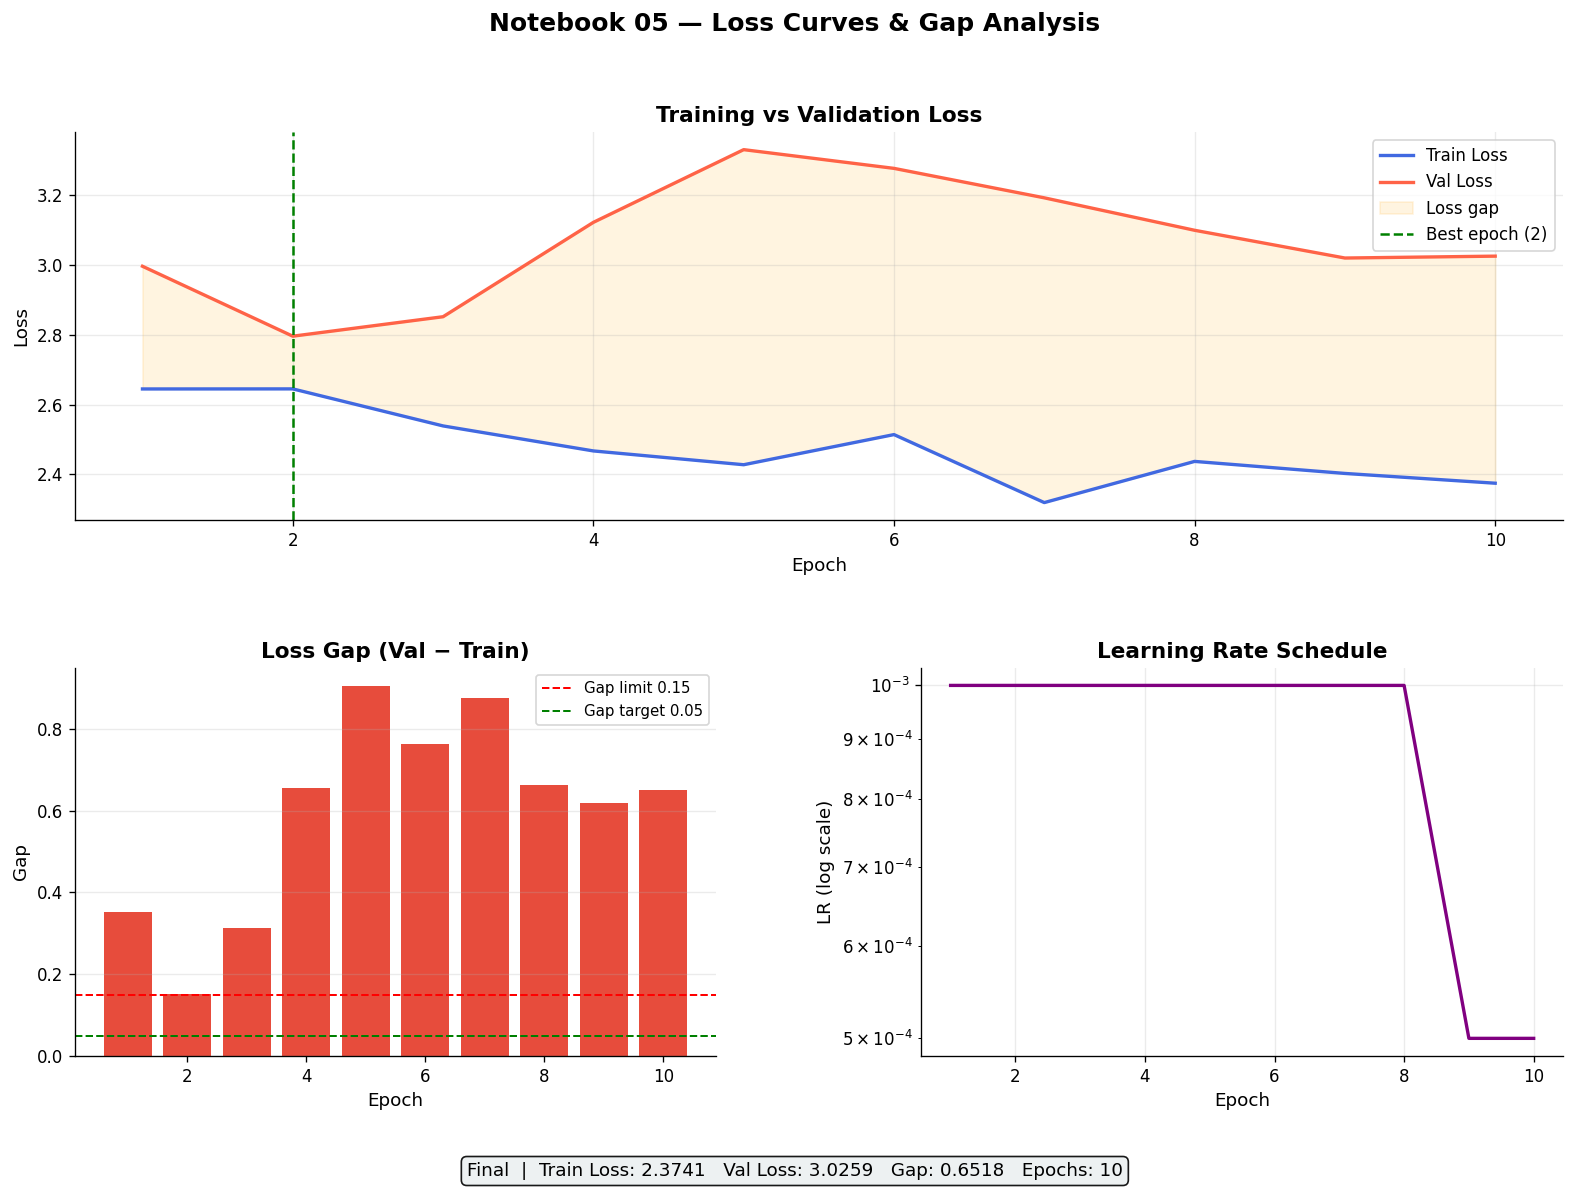

In [10]:
epochs = range(1, epochs_trained + 1)
train_loss = history['train_loss']
val_loss   = history['val_loss']
loss_gap   = [v - t for t, v in zip(train_loss, val_loss)]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── Panel A: Loss curves ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(epochs, train_loss, 'royalblue', lw=2,   label='Train Loss')
ax1.plot(epochs, val_loss,   'tomato',    lw=2,   label='Val Loss')
ax1.fill_between(epochs, train_loss, val_loss,
                 alpha=0.12, color='orange', label='Loss gap')

best_epoch = val_loss.index(min(val_loss)) + 1
ax1.axvline(best_epoch, ls='--', color='green', lw=1.5,
            label=f'Best epoch ({best_epoch})')
ax1.set_title('Training vs Validation Loss', fontweight='bold', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.25)

# ── Panel B: Loss gap per epoch ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
colors_gap = ['#e74c3c' if g > 0.15 else '#2ecc71' for g in loss_gap]
ax2.bar(epochs, loss_gap, color=colors_gap, edgecolor='none', width=0.8)
ax2.axhline(0.15, ls='--', color='red',   lw=1.2, label='Gap limit 0.15')
ax2.axhline(0.05, ls='--', color='green', lw=1.2, label='Gap target 0.05')
ax2.set_title('Loss Gap (Val − Train)', fontweight='bold', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Gap')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.25)

# ── Panel C: Learning rate trace ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.semilogy(epochs, history['lr'], color='purple', lw=2)
ax3.set_title('Learning Rate Schedule', fontweight='bold', fontsize=13)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('LR (log scale)')
ax3.grid(alpha=0.25)

# ── Summary box ───────────────────────────────────────────────────────────────
final_gap = loss_gap[-1]
fig.text(
    0.5, 0.01,
    f'Final  |  Train Loss: {train_loss[-1]:.4f}   Val Loss: {val_loss[-1]:.4f}   '
    f'Gap: {final_gap:.4f}   Epochs: {epochs_trained}',
    ha='center', fontsize=11,
    bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.9)
)

fig.suptitle('Notebook 05 — Loss Curves & Gap Analysis', fontsize=15, fontweight='bold')

loss_plot_path = REPORTS_DIR / '05a_loss_curves.png'
plt.savefig(loss_plot_path, dpi=200, bbox_inches='tight')
print(f'✅ Saved: {loss_plot_path}')
plt.show()

### b · Accuracy Curves (Top-1 & Top-3)

✅ Saved: /content/drive/MyDrive/Project2_AgroLens_AI/reports/05b_accuracy_curves.png


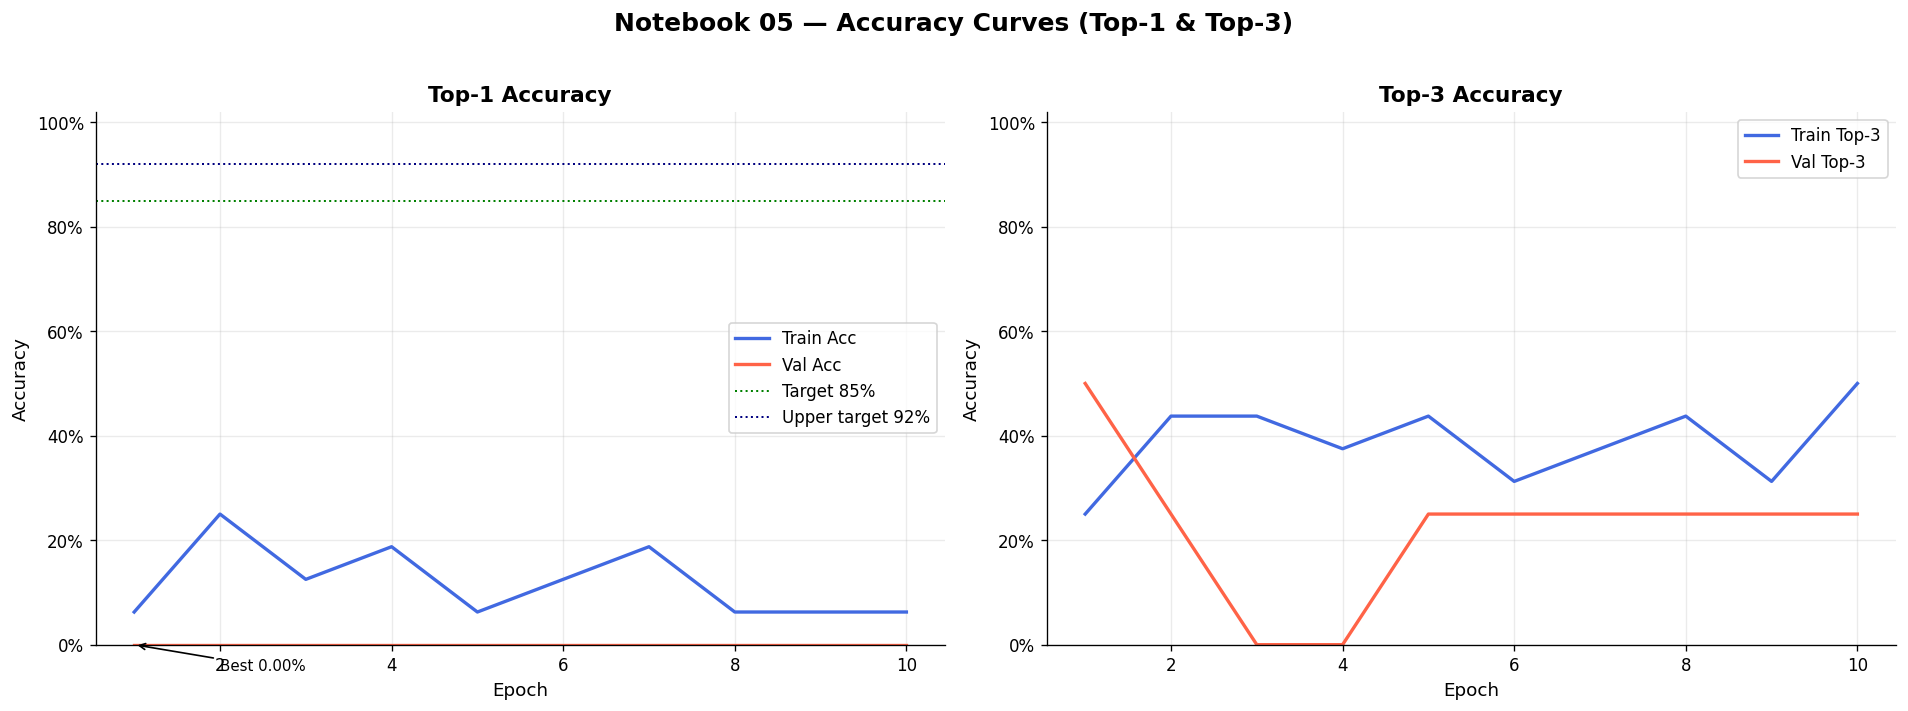

In [11]:
train_acc  = history['train_acc']
val_acc    = history['val_acc']
train_top3 = history['train_top3']
val_top3   = history['val_top3']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Top-1 Accuracy ────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs, train_acc, 'royalblue', lw=2,  label='Train Acc')
ax.plot(epochs, val_acc,   'tomato',    lw=2,  label='Val Acc')
ax.axhline(0.85, ls=':', color='green', lw=1.2, label='Target 85%')
ax.axhline(0.92, ls=':', color='navy',  lw=1.2, label='Upper target 92%')
ax.set_ylim(0, 1.02)
ax.set_title('Top-1 Accuracy', fontweight='bold', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=10)
ax.grid(alpha=0.25)

# Annotate best val acc
best_top1_epoch = val_acc.index(max(val_acc)) + 1
ax.annotate(
    f'Best {max(val_acc):.2%}',
    xy=(best_top1_epoch, max(val_acc)),
    xytext=(best_top1_epoch + 1, max(val_acc) - 0.05),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9,
)

# ── Top-3 Accuracy ────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs, train_top3, 'royalblue', lw=2,  label='Train Top-3')
ax.plot(epochs, val_top3,   'tomato',    lw=2,  label='Val Top-3')
ax.set_ylim(0, 1.02)
ax.set_title('Top-3 Accuracy', fontweight='bold', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=10)
ax.grid(alpha=0.25)

fig.suptitle('Notebook 05 — Accuracy Curves (Top-1 & Top-3)', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])

acc_plot_path = REPORTS_DIR / '05b_accuracy_curves.png'
plt.savefig(acc_plot_path, dpi=200, bbox_inches='tight')
print(f'✅ Saved: {acc_plot_path}')
plt.show()

##  Final Metrics Summary

Fill in the **RECORD THESE VALUES** table from the task specification.

In [12]:
final_train_loss = history['train_loss'][-1]
final_val_loss   = history['val_loss'][-1]
final_loss_gap   = final_val_loss - final_train_loss
final_train_acc  = history['train_acc'][-1]
final_val_acc    = history['val_acc'][-1]
best_val_acc_val = max(history['val_acc'])

# ── Diagnostics ───────────────────────────────────────────────────────────────
def diagnose(train_loss, val_loss, gap):
    issues = []
    if np.isnan(train_loss):
        issues.append('❌ Loss = NaN  → Reduce learning rate')
    if abs(train_loss - val_loss) < 0.01 and train_loss > 1.0:
        issues.append('❌ Loss barely moving → Check data normalisation')
    if gap > 0.2:
        issues.append('⚠️  Large gap → Possible overfitting; increase dropout / data augmentation')
    if gap < 0 and abs(gap) > 0.05:
        issues.append('⚠️  Negative gap → Model may be underfitting')
    if not issues:
        issues.append('✅ All metrics within target range')
    return issues

diag = diagnose(final_train_loss, final_val_loss, final_loss_gap)

print('=' * 60)
print('         TRAINING RESULTS — RECORD THESE VALUES')
print('=' * 60)
print(f'  Training Loss    : {final_train_loss:.4f}')
print(f'  Validation Loss  : {final_val_loss:.4f}')
print(f'  Loss Gap         : {final_loss_gap:.4f}   ← KEY METRIC')
print(f'  Training Acc     : {final_train_acc:.4f}  ({final_train_acc*100:.2f}%)')
print(f'  Validation Acc   : {final_val_acc:.4f}  ({final_val_acc*100:.2f}%)')
print(f'  Best Val Acc     : {best_val_acc_val:.4f}  ({best_val_acc_val*100:.2f}%)')
print(f'  Epochs Trained   : {epochs_trained}')
print(f'  Best checkpoint  : {MODELS_DIR / "best_model.pth"}')
print('=' * 60)
print('\nDIAGNOSTICS:')
for d in diag:
    print(f'  {d}')
print('=' * 60)
print('\n📊 TensorBoard:')
print(f'   tensorboard --logdir "{LOGS_DIR}"')

         TRAINING RESULTS — RECORD THESE VALUES
  Training Loss    : 2.3741
  Validation Loss  : 3.0259
  Loss Gap         : 0.6518   ← KEY METRIC
  Training Acc     : 0.0625  (6.25%)
  Validation Acc   : 0.0000  (0.00%)
  Best Val Acc     : 0.0000  (0.00%)
  Epochs Trained   : 10
  Best checkpoint  : /content/drive/MyDrive/Project2_AgroLens_AI/models/best_model.pth

DIAGNOSTICS:
  ⚠️  Large gap → Possible overfitting; increase dropout / data augmentation

📊 TensorBoard:
   tensorboard --logdir "/content/drive/MyDrive/Project2_AgroLens_AI/logs/tensorboard"


##  Load Best Weights & Verify

Quick sanity check — reload the saved checkpoint and run one validation pass to confirm the weights are intact.

In [13]:
best_ckpt = MODELS_DIR / 'best_model.pth'
model_verify = BaselineCNN(input_channels=IMG_CHANNELS, num_classes=NUM_CLASSES).to(DEVICE)
model_verify.load_state_dict(torch.load(best_ckpt, map_location=DEVICE, weights_only=True))

v_loss_ck, v_acc_ck, v_top3_ck = evaluate(model_verify, val_loader, criterion, DEVICE)

print(f'✅ Checkpoint reloaded from: {best_ckpt}')
print(f'   Val Loss  : {v_loss_ck:.4f}')
print(f'   Val Top-1 : {v_acc_ck:.4f}  ({v_acc_ck*100:.2f}%)')
print(f'   Val Top-3 : {v_top3_ck:.4f}  ({v_top3_ck*100:.2f}%)')

✅ Checkpoint reloaded from: /content/drive/MyDrive/Project2_AgroLens_AI/models/best_model.pth
   Val Loss  : 2.7962
   Val Top-1 : 0.0000  (0.00%)
   Val Top-3 : 0.2500  (25.00%)
